In [1]:
import torch as t
import numpy as np 
import torch.nn as nn
import torch.optim as optim 
import torch.nn.functional as F 
import matplotlib.pyplot as plt 
import random
from Functions import *

-68.70101241711443


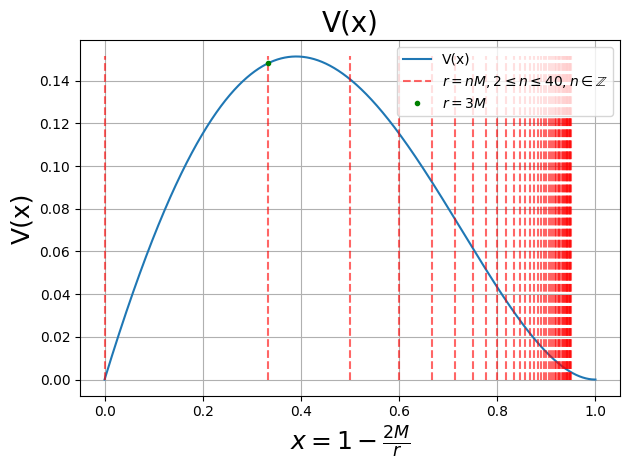

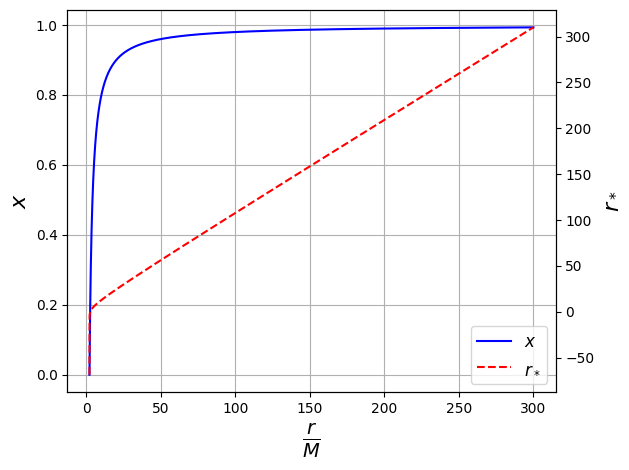

In [36]:
M = 1
l = 2#
eps = 1e-15
x = np.linspace(0, 1, 100000)
r = np.linspace(2 + eps, 300, 100000)
x_coord = r_to_x(r, M)
rstar_coord = r_to_rstar(r, M)

print(np.min(rstar_coord))

def Vx(x, M, l):
    return x*(1-x)**2/(4*M**2)*(l*(l+1) - 3*(1-x))

light_ring = 1-2*M/3*M

radii = np.array(range(39)) + 2

# xs = []
# for r in radii:
#     xs.append(r_to_x(r, M))

plt.figure()
plt.plot(x, Vx(x, M, l), label = r'V(x)')
plt.vlines(1 - 2*M/radii, [0]*len(radii), [np.max(Vx(x, M, l))]*len(radii), 'r', 'dashed', alpha = 0.6, label = r'$ r = nM, 2 \leq n \leq 40, n \in \mathbb{Z}$')
plt.plot(light_ring, Vx(light_ring, M, l), '.', color = 'green', label = r'$r = 3M$')
plt.xlabel(r'$x = 1 - \frac{2M}{r}$', fontsize = 18)
plt.ylabel('V(x)', fontsize = 18)
plt.title('V(x)', fontsize = 20)
plt.tight_layout()
plt.grid()
plt.legend()
plt.show()

fig, ax1 = plt.subplots()
line1 = ax1.plot(r, x_coord, color = 'blue', label=r'$x$')
ax1.set_xlabel(r'$\frac{r}{M}$', fontsize=20)
ax1.set_ylabel(r'$x$', fontsize=16)
ax1.tick_params(axis = 'y')
ax1.grid(True)

ax2 = ax1.twinx()
line2 = ax2.plot(r, rstar_coord, color = 'red', linestyle='--', label=r'$r_*$')
ax2.set_ylabel(r'$r_*$', fontsize=16)
ax2.tick_params(axis='y')

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, fontsize = 'large', loc='lower right')
fig.tight_layout()  
plt.show()


In [2]:
#PINN architecture
class Model(nn.Module):
    def __init__(self, in_channels, out_channels, hidden_channels, num_hidden_layers=2):
        super().__init__() 
        self.input_layer = nn.Linear(in_channels, hidden_channels)
        self.hidden_layers = nn.ModuleList([nn.Linear(hidden_channels, hidden_channels) for _ in range(num_hidden_layers)]) 
        self.output_layer = nn.Linear(hidden_channels, out_channels) 

    def forward(self, x: t.tensor):
        #x is a tensor with shape [batch_size, in_channels]
        x = F.tanh(self.input_layer(x)) 
        #x leaves as tensor with shape [batch_size, hidden_channels]
        for hidden_layer in self.hidden_layers:
            x = F.tanh(hidden_layer(x))
        #x leaves as tensor with shape [batch_size, output_channels]
        x = self.output_layer(x) 
        return x 

In [ ]:
M = 1
rstar_max = 800
rstar_min = -800
r_max = rstar_to_r(rstar_max, M)
r_min = rstar_to_r(rstar_min, M)
dx = 0.08
x_max = r_to_x(r_max, M)
x_min = r_to_x(r_min, M)

x = np.arange(x_min*M, (x_max + dx)*M, dx)
r = rstar_to_r(x, M)
axialV = Vpm(r, M, l = 2, parity = 'axial')

xtensor = t.tensor(x, dtype = t.float64, requires_grad = True)

In [4]:
#Initial Condition
rs_IC = gaussian_wave(rstar, 0, 200*M, 10*M, 0.7) 
t_IC = np.zeros_like(rs_IC)
tx_IC = t.tensor(np.stack([t_IC, rs_IC], axis = 1))
